# GREEDY CENTROID

/tmp/ipykernel_11106/642763360.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', len(self.agents))


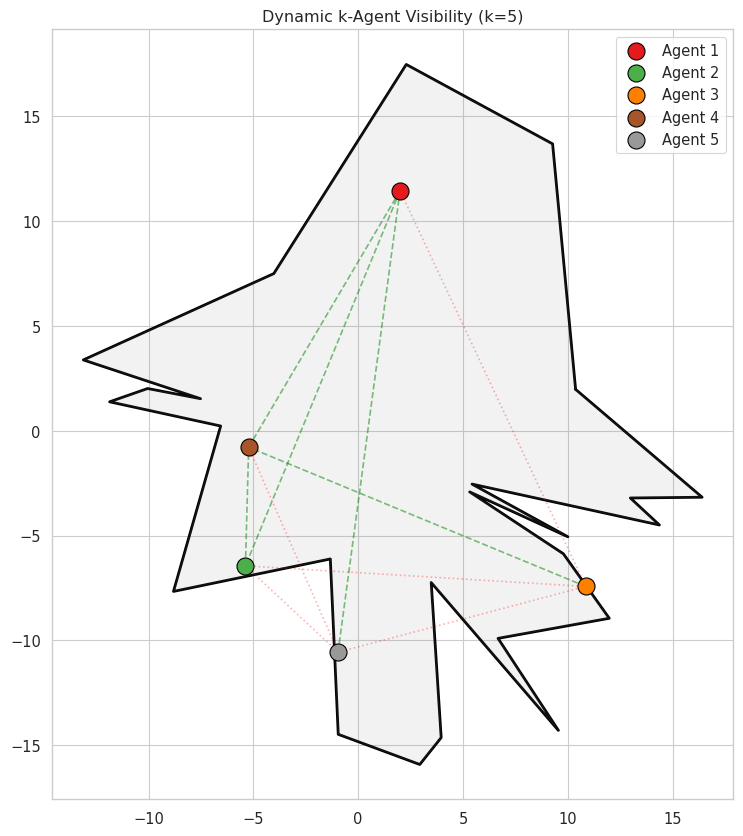

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point, LineString
from shapely.strtree import STRtree

class PolygonGenerator:
    @staticmethod
    def generate_star_polygon(num_vertices: int, center=(0, 0), min_radius=2.0, max_radius=15.0) -> list:
        # Generate random angles between 0 and 2*PI and sort them
        angles = np.sort(np.random.uniform(0, 2 * np.pi, num_vertices))
        # Generate random radii for each angle
        radii = np.random.uniform(min_radius, max_radius, num_vertices)

        x_coords = center[0] + radii * np.cos(angles)
        y_coords = center[1] + radii * np.sin(angles)
        return list(zip(x_coords, y_coords))

    @staticmethod
    def generate_chaotic_polygon(num_vertices: int, width=100, height=100) -> list:
        while True:
            # Scatter random points
            points = np.random.uniform(low=0, high=width, size=(num_vertices, 2))
            order = list(range(num_vertices))

            # Iteratively untangle crossing edges
            changed = True
            max_iterations = 1000
            iterations = 0

            while changed and iterations < max_iterations:
                changed = False
                iterations += 1
                for i in range(num_vertices):
                    for j in range(i + 2, num_vertices):
                        # Don't check adjacent edges
                        if (j + 1) % num_vertices == i:
                            continue

                        # Get the two line segments
                        p1, p2 = points[order[i]], points[order[(i+1)%num_vertices]]
                        p3, p4 = points[order[j]], points[order[(j+1)%num_vertices]]

                        l1 = LineString([p1, p2])
                        l2 = LineString([p3, p4])

                        # If they cross, reverse the sequence of points between them to untangle
                        if l1.crosses(l2):
                            order[i+1:j+1] = reversed(order[i+1:j+1])
                            changed = True
                            break # Break inner loop to restart with new order
                    if changed:
                        break # Break outer loop

            # Extract the final untangled coordinates
            final_coords = [tuple(points[idx]) for idx in order]

            test_poly = Polygon(final_coords)
            if test_poly.is_simple and test_poly.area > (width * height * 0.05):
                return final_coords

    @staticmethod
    def spawn_random_agents(polygon: Polygon, num_agents: int) -> list:
        agents = []
        minx, miny, maxx, maxy = polygon.bounds
        while len(agents) < num_agents:
            rand_point = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
            if polygon.contains(rand_point):
                agents.append((rand_point.x, rand_point.y))
        return agents


class Agent:
    def __init__(self, agent_id: int, start_x: float, start_y: float):
        self.id = agent_id
        self.position = Point(start_x, start_y)
        self.history = [self.position]
        self.current_visibility_polygon = None

    def move_to(self, new_x: float, new_y: float):
        self.position = Point(new_x, new_y)
        self.history.append(self.position)

class Environment:
    def __init__(self, boundary_coords: list):
        self.polygon = Polygon(boundary_coords)
        if not self.polygon.is_simple:
            raise ValueError("The provided coordinates do not form a simple polygon.")

        self.edges = []
        coords = list(self.polygon.exterior.coords)
        for i in range(len(coords) - 1):
            self.edges.append(LineString([coords[i], coords[i+1]]))

        # Build the STRtree (Spatial Sort) for O(log n) ray-casting queries
        self.spatial_index = STRtree(self.edges)
        self.agents = []

    def add_agent(self, agent: Agent):
        if not self.polygon.contains(agent.position):
            raise ValueError(f"Agent {agent.id} spawned outside the polygon boundary")
        self.agents.append(agent)

    def check_mutual_visibility(self, agent_a: Agent, agent_b: Agent) -> bool:
        sightline = LineString([agent_a.position, agent_b.position])

        # Fast spatial query
        possible_blockers = self.spatial_index.query(sightline)
        for edge_idx in possible_blockers:
            if sightline.crosses(self.edges[edge_idx]):
                return False

        # Check if sightline passes outside a non-convex corner
        midpoint = Point(sightline.interpolate(0.5, normalized=True))
        if not self.polygon.contains(midpoint):
            return False
        return True

    def check_global_mutual_visibility(self) -> bool:
        # If there are less than 2 agents, visibility is trivially true
        if len(self.agents) < 2:
            return True

        # Check every unique pair of agents
        for i in range(len(self.agents)):
            for j in range(i + 1, len(self.agents)):
                # If even one pair is blocked, the win condition is not met
                if not self.check_mutual_visibility(self.agents[i], self.agents[j]):
                    return False

        # If loop finishes without returning False, everyone can see everyone
        return True

    def render(self):
        fig, ax = plt.subplots(figsize=(10, 10))

        # Draw Polygon
        x, y = self.polygon.exterior.xy
        ax.plot(x, y, color='black', linewidth=2, zorder=1)
        ax.fill(x, y, alpha=0.1, color='gray')

        # Draw Agents
        colors = plt.cm.get_cmap('Set1', len(self.agents))
        for i, agent in enumerate(self.agents):
            px, py = agent.position.x, agent.position.y
            ax.scatter(px, py, color=colors(i), s=150, label=f"Agent {agent.id}", edgecolors='black', zorder=5)

            # Draw line-of-sight to other agents if visible
            for other_agent in self.agents[i+1:]:
                if self.check_mutual_visibility(agent, other_agent):
                    ax.plot([px, other_agent.position.x], [py, other_agent.position.y],
                            color='green', linestyle='--', alpha=0.5, zorder=2)
                else:
                    ax.plot([px, other_agent.position.x], [py, other_agent.position.y],
                            color='red', linestyle=':', alpha=0.3, zorder=2)

        ax.set_aspect('equal')
        ax.set_title(f"Dynamic k-Agent Visibility (k={len(self.agents)})")
        plt.legend()
        plt.show()

    def get_visibility_polygon(self, agent: Agent, num_rays=180) -> Polygon:
        px, py = agent.position.x, agent.position.y
        # Determine a ray length guaranteed to hit the polygon walls
        max_dist = np.max([self.polygon.bounds[2] - self.polygon.bounds[0],
                           self.polygon.bounds[3] - self.polygon.bounds[1]]) * 2

        hit_points = []
        for angle in np.linspace(0, 2 * np.pi, num_rays, endpoint=False):
            # Create a long ray in this specific direction
            ray_end_x = px + max_dist * np.cos(angle)
            ray_end_y = py + max_dist * np.sin(angle)
            ray = LineString([(px, py), (ray_end_x, ray_end_y)])

            # Intersect the ray with the environment boundary
            intersection = ray.intersection(self.polygon.exterior)

            if intersection.is_empty:
                continue

            # Extract the closest point of intersection
            if intersection.geom_type == 'Point':
                hit_points.append((intersection.x, intersection.y))
            elif intersection.geom_type in ['MultiPoint', 'GeometryCollection']:
                # Filter to only Points and find the closest one
                pts = [geom for geom in getattr(intersection, 'geoms', [intersection]) if geom.geom_type == 'Point']
                if pts:
                    closest_pt = min(pts, key=lambda pt: agent.position.distance(pt))
                    hit_points.append((closest_pt.x, closest_pt.y))

        # Create a polygon from the hit points and ensure it stays strictly inside the walls
        vis_poly = Polygon(hit_points)
        return vis_poly.intersection(self.polygon)

    def step_centroid_heuristic(self, step_size=0.5):
        # Calculate visibility pools for all agents
        vis_polys = []
        for agent in self.agents:
            vp = self.get_visibility_polygon(agent)
            agent.current_visibility_polygon = vp
            vis_polys.append(vp)

        # Find the shared mathematical intersection of all visibility pools
        shared_region = vis_polys[0]
        for vp in vis_polys[1:]:
            shared_region = shared_region.intersection(vp)

        # If there is no shared region, the heuristic fails
        if shared_region.is_empty:
            return None

        # Find the centroid of the shared region
        target_centroid = shared_region.centroid

        # Move all agents one step toward the centroid
        for agent in self.agents:
            dx = target_centroid.x - agent.position.x
            dy = target_centroid.y - agent.position.y
            dist = np.hypot(dx, dy)

            # Move by step_size, but don't overshoot if we are already close
            if dist > 0.1:
                move_ratio = min(step_size / dist, 1.0)
                new_x = agent.position.x + dx * move_ratio
                new_y = agent.position.y + dy * move_ratio
                agent.move_to(new_x, new_y)

        return shared_region

# Generate a random jagged polygon
# poly_coords = PolygonGenerator.generate_chaotic_polygon(num_vertices=20, width=40, height=40)
# env = Environment(poly_coords)

poly_coords = PolygonGenerator.generate_star_polygon(num_vertices=25, min_radius=6.0, max_radius=18.0)
env = Environment(poly_coords)

# agent_positions = PolygonGenerator.spawn_random_agents(env.polygon, num_agents=5)
# for i, (ax_x, ax_y) in enumerate(agent_positions):
#     env.add_agent(Agent(agent_id=i+1, start_x=ax_x, start_y=ax_y))


agent_positions = PolygonGenerator.spawn_random_agents(env.polygon, num_agents=5)

for i, (ax_x, ax_y) in enumerate(agent_positions):
    new_agent = Agent(agent_id=i+1, start_x=ax_x, start_y=ax_y)
    env.add_agent(new_agent)

env.render()

SUCCESS: Mutual visibility achieved at Step 6


/tmp/ipykernel_11106/123131476.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', len(env.agents))


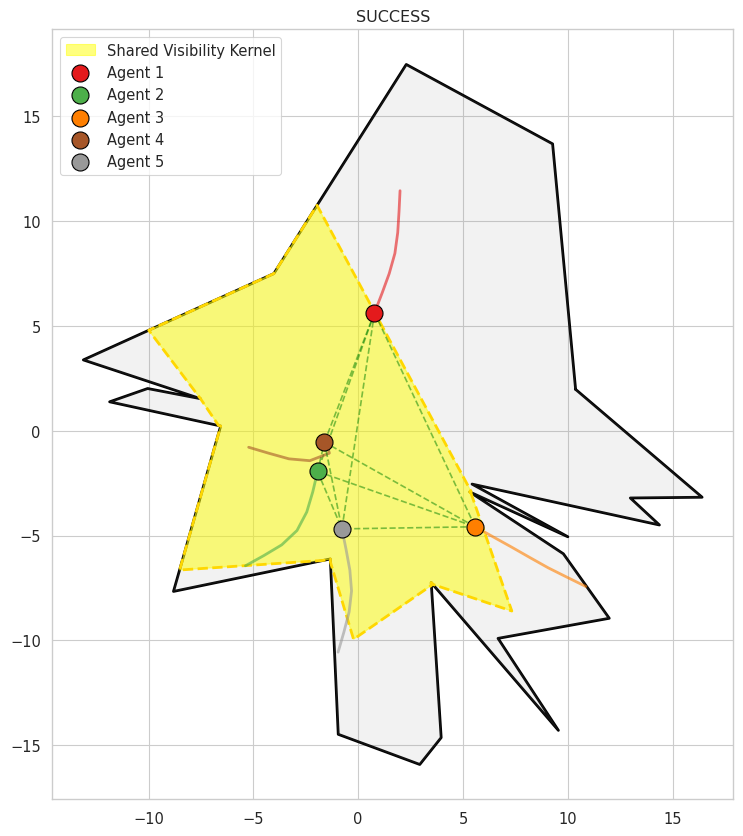

In [16]:

simulation_steps = 15
final_shared_region = None
success = False

# Check if they are spawn already able to see each other
if env.check_global_mutual_visibility():
    print("SUCCESS: Mutual visibility achieved at Step 0")
    success = True
else:
    for step in range(1, simulation_steps + 1):
        shared_region = env.step_centroid_heuristic(step_size=1.0)

        if not shared_region:
            print(f"FAILED at Step {step}: Agents lost shared line of sight")
            break

        final_shared_region = shared_region

        if env.check_global_mutual_visibility():
            print(f"SUCCESS: Mutual visibility achieved at Step {step}")
            success = True
            break

    if not success and shared_region:
         print(f"TIMEOUT: Reached {simulation_steps} steps without full mutual visibility.")


fig, ax = plt.subplots(figsize=(10, 10))

x, y = env.polygon.exterior.xy
ax.plot(x, y, color='black', linewidth=2, zorder=1)
ax.fill(x, y, alpha=0.1, color='gray')

if final_shared_region and not final_shared_region.is_empty:
    if final_shared_region.geom_type == 'Polygon':
        rx, ry = final_shared_region.exterior.xy
        ax.fill(rx, ry, color='yellow', alpha=0.5, label="Shared Visibility Kernel")
        ax.plot(rx, ry, color='gold', linewidth=2, linestyle='--')

colors = plt.cm.get_cmap('Set1', len(env.agents))
for i, agent in enumerate(env.agents):
    if len(agent.history) > 1:
        hx, hy = zip(*[(p.x, p.y) for p in agent.history])
        ax.plot(hx, hy, color=colors(i), linestyle='-', linewidth=2, alpha=0.6)

    ax.scatter(agent.position.x, agent.position.y, color=colors(i), s=150, edgecolors='black', zorder=5, label=f"Agent {agent.id}")

    # Draw the winning lines of sight
    if success:
        for other_agent in env.agents[i+1:]:
            ax.plot([agent.position.x, other_agent.position.x],
                    [agent.position.y, other_agent.position.y],
                    color='green', linestyle='--', alpha=0.5, zorder=2)

ax.set_aspect('equal')
title_status = "SUCCESS" if success else "FAILED"
ax.set_title(f"{title_status}")
plt.legend()
plt.show()

# GEODESIC DECOMPOSITION

/tmp/ipykernel_11106/1146833366.py:263: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


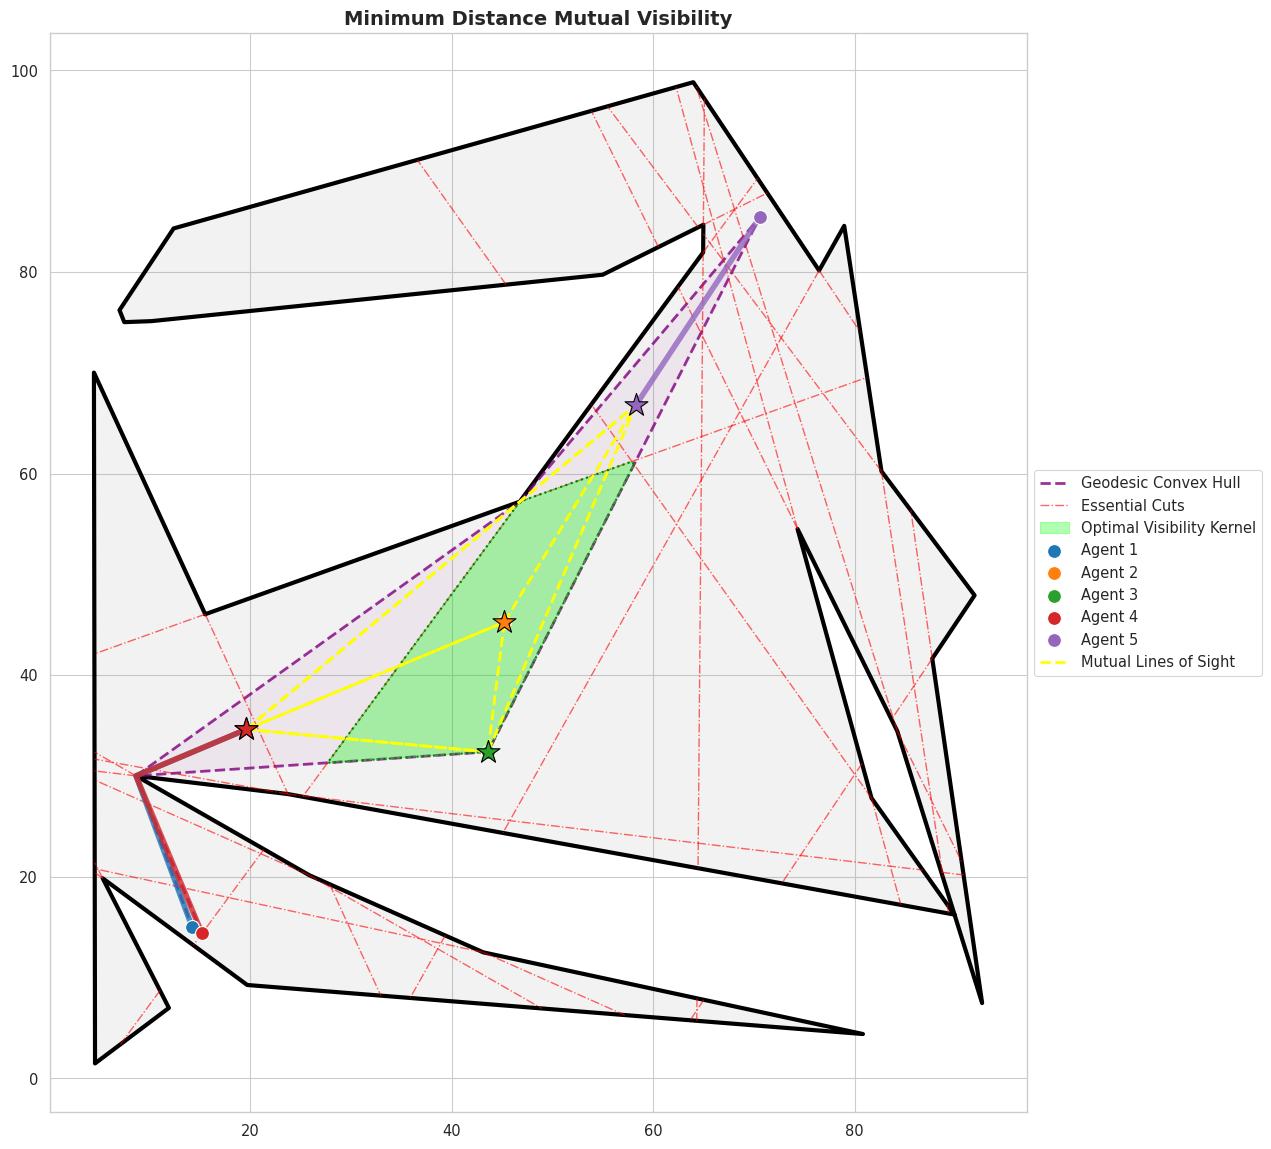

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point, LineString, MultiLineString
from shapely.strtree import STRtree
from shapely.ops import split
import networkx as nx
from scipy.spatial import ConvexHull

class PolygonGenerator:
    @staticmethod
    def generate_chaotic_polygon(num_vertices: int, width=100, height=100) -> list:
        while True:
            points = np.random.uniform(low=0, high=width, size=(num_vertices, 2))
            order = list(range(num_vertices))
            changed = True
            iterations = 0
            while changed and iterations < 1000:
                changed = False
                iterations += 1
                for i in range(num_vertices):
                    for j in range(i + 2, num_vertices):
                        if (j + 1) % num_vertices == i: continue
                        p1, p2 = points[order[i]], points[order[(i+1)%num_vertices]]
                        p3, p4 = points[order[j]], points[order[(j+1)%num_vertices]]
                        if LineString([p1, p2]).crosses(LineString([p3, p4])):
                            order[i+1:j+1] = reversed(order[i+1:j+1])
                            changed = True; break
                    if changed: break
            final_coords = [tuple(points[idx]) for idx in order]
            test_poly = Polygon(final_coords)
            if test_poly.is_simple and test_poly.area > (width * height * 0.05):
                return final_coords

class TopologicalEnvironment:
    def __init__(self, boundary_coords: list):
        self.polygon = Polygon(boundary_coords)
        self.exterior_coords = list(self.polygon.exterior.coords)[:-1]
        if not self.polygon.exterior.is_ccw:
            self.exterior_coords.reverse()
            self.polygon = Polygon(self.exterior_coords)

        self.edges = [LineString([self.polygon.exterior.coords[i], self.polygon.exterior.coords[i+1]])
                      for i in range(len(self.polygon.exterior.coords) - 1)]
        self.spatial_index = STRtree(self.edges)
        self.vertices = self.exterior_coords
        self.graph = nx.Graph()
        self.all_nodes_cache = [] # Cache to hold vertices + agents

    def check_los(self, p1: tuple, p2: tuple) -> bool:
        sightline = LineString([p1, p2])
        for edge_idx in self.spatial_index.query(sightline):
            if sightline.crosses(self.edges[edge_idx]): return False
        midpoint = Point(sightline.interpolate(0.5, normalized=True))
        if not self.polygon.contains(midpoint) and not self.polygon.touches(midpoint): return False
        return True

    def build_visibility_graph(self, agent_positions: list):
        self.graph.clear()
        self.all_nodes_cache = self.vertices + agent_positions
        for i, node in enumerate(self.all_nodes_cache):
            self.graph.add_node(i, pos=node)

        for i in range(len(self.all_nodes_cache)):
            for j in range(i + 1, len(self.all_nodes_cache)):
                if self.check_los(self.all_nodes_cache[i], self.all_nodes_cache[j]):
                    dist = np.hypot(self.all_nodes_cache[j][0] - self.all_nodes_cache[i][0],
                                    self.all_nodes_cache[j][1] - self.all_nodes_cache[i][1])
                    self.graph.add_edge(i, j, weight=dist)

    def get_geodesic_convex_hull(self, agent_positions: list) -> Polygon:
        if len(agent_positions) < 3: return Polygon()
        try: hull_indices = ConvexHull(np.array(agent_positions)).vertices
        except Exception: return Polygon()

        offset = len(self.vertices)
        graph_nodes = [i + offset for i in hull_indices]
        loop = []
        for i in range(len(graph_nodes)):
            try:
                path_idx = nx.shortest_path(self.graph, source=graph_nodes[i], target=graph_nodes[(i + 1) % len(graph_nodes)], weight='weight')
                path = [self.graph.nodes[n]['pos'] for n in path_idx]
                if loop and len(path) > 0: loop.extend(path[1:])
                else: loop.extend(path)
            except nx.NetworkXNoPath: continue
        hull_poly = Polygon(loop)
        return hull_poly.buffer(0) if not hull_poly.is_valid else hull_poly

    def get_essential_cuts(self) -> list:
        cuts = []
        n = len(self.vertices)
        for i in range(n):
            p1, p2, p3 = self.vertices[i-1], self.vertices[i], self.vertices[(i+1)%n]
            if (p2[0]-p1[0])*(p3[1]-p2[1]) - (p2[1]-p1[1])*(p3[0]-p2[0]) < 0: # Reflex check
                for dx, dy in [(p2[0]-p1[0], p2[1]-p1[1]), (p2[0]-p3[0], p2[1]-p3[1])]:
                    mag = np.hypot(dx, dy)
                    ray = LineString([p2, (p2[0]+(dx/mag)*1000, p2[1]+(dy/mag)*1000)])
                    cut = self.polygon.intersection(ray)
                    if cut.geom_type == 'LineString': cuts.append(cut)
                    elif cut.geom_type in ['MultiLineString', 'GeometryCollection']:
                        cuts.extend([g for g in getattr(cut, 'geoms', [cut]) if g.geom_type == 'LineString'])
        return cuts

    def find_optimal_meeting_cell(self, hull: Polygon, cuts: list, agents: list):
        if hull.is_empty: return None, [], []

        # Fracture the hull into convex sub-cells
        splitter = MultiLineString(cuts)
        try:
            all_cells = [geom for geom in split(hull, splitter).geoms if geom.geom_type == 'Polygon']
        except Exception:
            all_cells = [hull]

        best_cell = None
        min_total_dist = float('inf')
        best_routes = []

        agent_start_indices = [len(self.vertices) + i for i in range(len(agents))]

        # Sweep every cell to calculate the geodesic walking distance
        for cell in all_cells:
            # Drop a temporary target point into the center of the room
            target_pt = cell.representative_point()
            target_coord = (target_pt.x, target_pt.y)
            target_node_idx = len(self.all_nodes_cache)

            self.graph.add_node(target_node_idx, pos=target_coord)
            for i, node_pos in enumerate(self.all_nodes_cache):
                if self.check_los(target_coord, node_pos):
                    dist = np.hypot(node_pos[0] - target_coord[0], node_pos[1] - target_coord[1])
                    self.graph.add_edge(target_node_idx, i, weight=dist)

            # Calculate how far each agent must walk to reach this room
            current_cell_dist = 0
            current_cell_routes = []
            possible = True

            for agent_idx in agent_start_indices:
                try:
                    # Run Dijkstra's to find the shortest path around the corners
                    path_indices = nx.shortest_path(self.graph, source=agent_idx, target=target_node_idx, weight='weight')
                    route_coords = [self.graph.nodes[i]['pos'] for i in path_indices]
                    route_length = nx.shortest_path_length(self.graph, source=agent_idx, target=target_node_idx, weight='weight')

                    current_cell_dist += route_length
                    current_cell_routes.append(route_coords)
                except nx.NetworkXNoPath:
                    possible = False # Should only happen if the polygon is physically fractured
                    break

            # Remove the temporary node to clean the graph for the next cell
            self.graph.remove_node(target_node_idx)

            # Update the optimal record
            if possible and current_cell_dist < min_total_dist:
                min_total_dist = current_cell_dist
                best_cell = cell
                best_routes = current_cell_routes

        return best_cell, best_routes, all_cells

def check_group_visibility(env, positions):
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            if not env.check_los(positions[i], positions[j]):
                return False
    return True

def interpolate_path(path, step_size=0.5):
    if not path: return []
    dense = [path[0]]
    for i in range(len(path) - 1):
        p1, p2 = np.array(path[i]), np.array(path[i+1])
        dist = np.linalg.norm(p2 - p1)
        if dist == 0: continue
        num_steps = int(np.ceil(dist / step_size))
        for j in range(1, num_steps + 1):
            dense.append(tuple(p1 + (p2 - p1) * (j / num_steps)))
    return dense

def optimize_stopping_points(env, optimal_routes):
    if not optimal_routes: return [], []
    dense_routes = [interpolate_path(r, step_size=0.5) for r in optimal_routes]
    current_indices = [len(r) - 1 for r in dense_routes]
    current_positions = [dense_routes[i][current_indices[i]] for i in range(len(dense_routes))]

    changed = True
    while changed:
        changed = False
        for i in range(len(dense_routes)):
            if current_indices[i] > 0:
                test_idx = current_indices[i] - 1
                test_positions = current_positions.copy()
                test_positions[i] = dense_routes[i][test_idx]
                if check_group_visibility(env, test_positions):
                    current_indices[i] = test_idx
                    current_positions[i] = test_positions[i]
                    changed = True

    threshold_routes = [dense_routes[i][:current_indices[i]+1] for i in range(len(dense_routes))]
    return threshold_routes, current_positions



num_agents_to_test = 5
poly_coords = PolygonGenerator.generate_chaotic_polygon(num_vertices=30, width=100, height=100)
env = TopologicalEnvironment(poly_coords)

minx, miny, maxx, maxy = env.polygon.bounds
agents = []
while len(agents) < num_agents_to_test:
    rp = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
    if env.polygon.contains(rp):
        agents.append((rp.x, rp.y))



#  Find the best neighborhood
env.build_visibility_graph(agents)
g_hull = env.get_geodesic_convex_hull(agents)
essential_cuts = env.get_essential_cuts()
optimal_cell, optimal_routes, all_cells = env.find_optimal_meeting_cell(g_hull, essential_cuts, agents)

#  Backtrack to find exact Distance-to-Sight thresholds
pruned_routes, final_stopping_points = optimize_stopping_points(env, optimal_routes)

original_dist = sum([LineString(r).length for r in optimal_routes if len(r) > 1])
optimized_dist = sum([LineString(r).length for r in pruned_routes if len(r) > 1])
savings = ((original_dist - optimized_dist) / original_dist) * 100 if original_dist > 0 else 0



fig, ax = plt.subplots(figsize=(12, 12))


x, y = env.polygon.exterior.xy
ax.plot(x, y, color='black', linewidth=3, zorder=2)
ax.fill(x, y, alpha=0.1, color='gray')

if not g_hull.is_empty:
    # Safely convert to an iterable whether it's a Polygon or MultiPolygon
    hulls = getattr(g_hull, 'geoms', [g_hull])

    for i, geom in enumerate(hulls):
        if geom.geom_type == 'Polygon':
            hx, hy = geom.exterior.xy
            # Only label the first piece to keep the legend clean
            label = "Geodesic Convex Hull" if i == 0 else ""
            ax.plot(hx, hy, color='purple', linewidth=2, linestyle='--', alpha=0.8, zorder=3, label=label)
            ax.fill(hx, hy, color='purple', alpha=0.05, zorder=2)

if essential_cuts:
    for i, cut in enumerate(essential_cuts):
        cx, cy = cut.xy
        # Only label the first one to avoid flooding the legend
        label = "Essential Cuts" if i == 0 else ""
        ax.plot(cx, cy, color='red', linewidth=1, linestyle='-.', alpha=0.6, zorder=4, label=label)

if optimal_cell:
    wx, wy = optimal_cell.exterior.xy
    ax.fill(wx, wy, color='lime', alpha=0.3, zorder=5, label="Optimal Visibility Kernel")
    ax.plot(wx, wy, color='green', linewidth=1.5, linestyle=':', zorder=6)

cmap = plt.cm.get_cmap('tab10')
for i, agent in enumerate(agents):
    color = cmap(i % 10)
    ax.scatter(*agent, color=color, s=100, zorder=9, edgecolors='white', label=f"Agent {i+1}")

    if pruned_routes and i < len(pruned_routes):
        # Plot the path they actually walked
        rx, ry = zip(*pruned_routes[i])
        ax.plot(rx, ry, color=color, linewidth=4, linestyle='-', alpha=0.8, zorder=8)

        # Plot the exact Distance-to-Sight threshold (where they stopped)
        stop_x, stop_y = final_stopping_points[i]
        ax.scatter(stop_x, stop_y, color=color, s=300, marker='*', zorder=11, edgecolors='black')

if final_stopping_points:
    for i in range(len(final_stopping_points)):
        for j in range(i + 1, len(final_stopping_points)):
            p1, p2 = final_stopping_points[i], final_stopping_points[j]
            # Only label the first sightline
            label = "Mutual Lines of Sight" if i == 0 and j == 1 else ""
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='yellow', linewidth=2, linestyle='--', zorder=10, label=label)

ax.set_aspect('equal')
title_text = f"Minimum Distance Mutual Visibility"
ax.set_title(title_text, fontsize=14, fontweight='bold')

# Move the legend outside the plot so it doesn't cover up the geometry
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# BENCHMARKING

Progress: 25/250
Progress: 50/250
Progress: 75/250
Progress: 100/250
Progress: 125/250
Progress: 150/250
Progress: 175/250
Progress: 200/250
Progress: 225/250
Progress: 250/250

EXPERIMENTAL RESULTS: SUMMARY TABLE

Mean Execution Time (ms) per Configuration:
Agents (k)         3       4       5       6
Vertices (n)                                
15             38.56   82.58  130.46  218.94
25            110.67  119.19  222.26  280.77
35            119.41  184.87  299.49  427.71
45            206.61  275.45  337.99  486.04
50            213.64  309.62  399.70  490.79


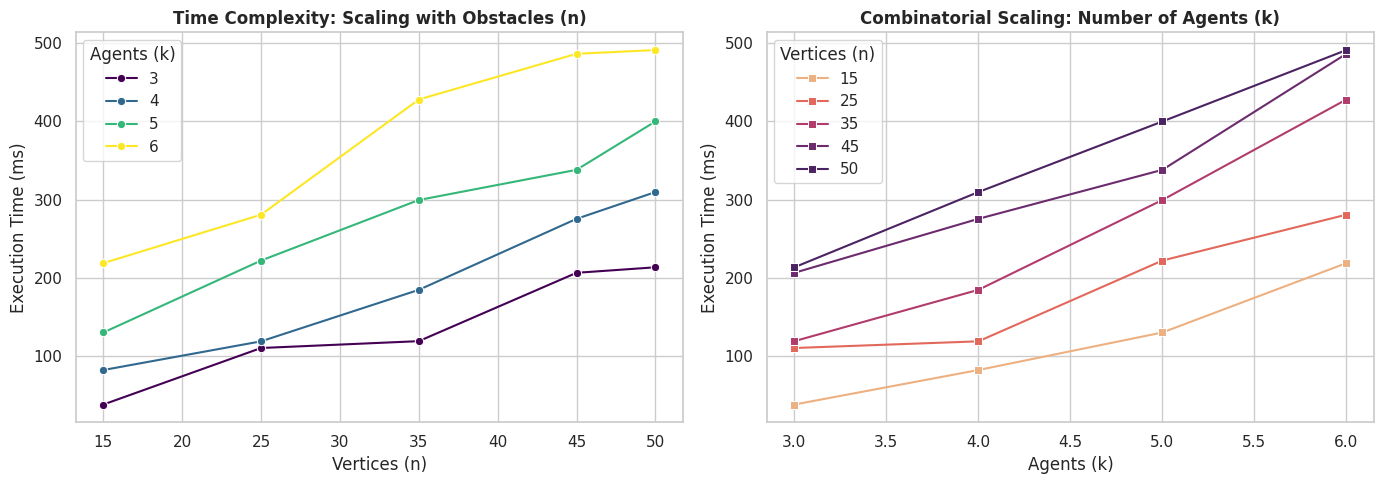

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

def run_headless_benchmark(trials_per_config=10, n_values=[15, 25, 35, 45, 50], k_values=[2, 3, 4, 5, 6]):
    results = []
    total_runs = len(n_values) * len(k_values) * trials_per_config
    current_run = 0

    for n in n_values:
        for k in k_values:
            for trial in range(trials_per_config):
                current_run += 1
                if current_run % 25 == 0:
                    print(f"Progress: {current_run}/{total_runs}")

                poly_coords = PolygonGenerator.generate_chaotic_polygon(num_vertices=n, width=100, height=100)
                env = TopologicalEnvironment(poly_coords)
                minx, miny, maxx, maxy = env.polygon.bounds
                agents = []
                while len(agents) < k:
                    rp = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
                    if env.polygon.contains(rp):
                        agents.append((rp.x, rp.y))

                start_time = time.perf_counter()

                # Full Pipeline Execution
                env.build_visibility_graph(agents)
                g_hull = env.get_geodesic_convex_hull(agents)
                essential_cuts = env.get_essential_cuts()
                # Finding the optimal room
                optimal_cell, optimal_routes, _ = env.find_optimal_meeting_cell(g_hull, essential_cuts, agents)
                # Refining the stopping points
                pruned_routes, _ = optimize_stopping_points(env, optimal_routes)

                exec_time_ms = (time.perf_counter() - start_time) * 1000
                success = bool(optimal_routes and pruned_routes)

                results.append({
                    "Vertices (n)": n,
                    "Agents (k)": k,
                    "Success": success,
                    "Execution Time (ms)": exec_time_ms
                })

    return pd.DataFrame(results)

# Execute
df_results = run_headless_benchmark()
df_clean = df_results[df_results["Success"] == True]

print("\n" + "="*50)
print("EXPERIMENTAL RESULTS: SUMMARY TABLE")
print("="*50)

summary_pivot = df_clean.pivot_table(
    values="Execution Time (ms)",
    index="Vertices (n)",
    columns="Agents (k)",
    aggfunc='mean'
)

print("\nMean Execution Time (ms) per Configuration:")
print(summary_pivot.round(2).to_string())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df_clean, x="Vertices (n)", y="Execution Time (ms)", hue="Agents (k)",
             marker="o", errorbar=None, ax=axes[0], palette="viridis")
axes[0].set_title("Time Complexity: Scaling with Obstacles (n)", fontweight='bold')

sns.lineplot(data=df_clean, x="Agents (k)", y="Execution Time (ms)", hue="Vertices (n)",
             marker="s", errorbar=None, ax=axes[1], palette="flare")
axes[1].set_title("Combinatorial Scaling: Number of Agents (k)", fontweight='bold')

plt.tight_layout()
plt.show()


Mean Execution Time (ms):
k                   2      3      4       5      6
Type        n                                     
Convex      10   0.16   0.13   0.19    0.30   0.42
            20   0.06   0.12   0.19    0.30   0.44
            30   0.06   0.12   0.20    0.29   0.42
Star-Shaped 10   6.66   0.22   0.65    0.56  70.76
            20   0.15  11.05   1.70   20.78   3.99
            30  20.78  33.65  50.63  159.18  88.14


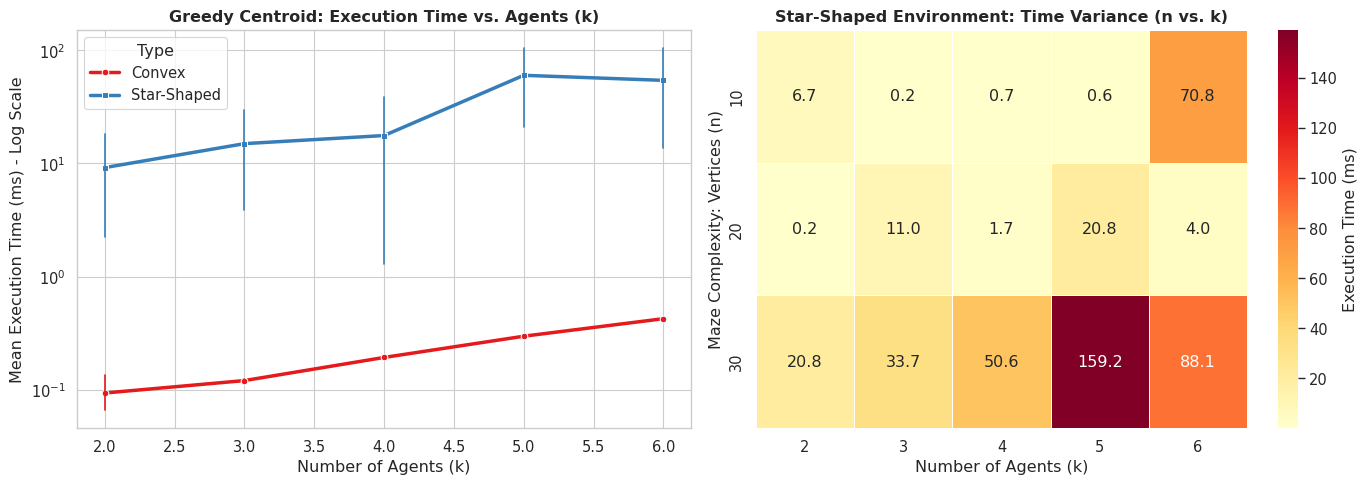

In [18]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

def generate_star_polygon(center=(50, 50), num_vertices=20, max_radius=40):
    angles = sorted(np.random.uniform(0, 2*np.pi, num_vertices))
    radii = np.random.uniform(max_radius * 0.3, max_radius, num_vertices)
    points = [(center[0] + r * np.cos(a), center[1] + r * np.sin(a)) for a, r in zip(angles, radii)]
    return points

def generate_convex_polygon(num_vertices=15):
    points = np.random.rand(num_vertices, 2) * 100
    hull = Polygon(points).convex_hull
    return list(hull.exterior.coords)

def run_greedy_benchmark(trials_per_config=10, n_values=[10, 20, 30], k_values=[2, 3, 4, 5, 6]):
    results = []

    for poly_type in ["Convex", "Star-Shaped"]:
        for n in n_values:
            for k in k_values:
                for trial in range(trials_per_config):
                    # 1. Environment Generation
                    if poly_type == "Convex":
                        coords = generate_convex_polygon(n)
                    else:
                        coords = generate_star_polygon(num_vertices=n)

                    poly = Polygon(coords)

                    minx, miny, maxx, maxy = poly.bounds
                    agents = []
                    while len(agents) < k:
                        rp = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
                        if poly.contains(rp):
                            agents.append(np.array([rp.x, rp.y]))

                    start_time = time.perf_counter()

                    curr_pos = [a.copy() for a in agents]
                    success = False
                    for _ in range(500):  # Max iterations
                        centroid = np.mean(curr_pos, axis=0)

                        # Check Mutual Visibility
                        visible_pairs = 0
                        total_pairs = k * (k-1) // 2
                        for i in range(k):
                            for j in range(i+1, k):
                                line = LineString([curr_pos[i], curr_pos[j]])
                                if poly.contains(line):
                                    visible_pairs += 1

                        if visible_pairs == total_pairs:
                            success = True
                            break

                        # Move toward centroid
                        for i in range(k):
                            dir_vec = centroid - curr_pos[i]
                            dist = np.linalg.norm(dir_vec)
                            if dist > 0.5:
                                step = (dir_vec / dist) * 1.0
                                next_p = curr_pos[i] + step
                                if poly.contains(Point(next_p)):
                                    curr_pos[i] = next_p

                    exec_time_ms = (time.perf_counter() - start_time) * 1000

                    results.append({
                        "Type": poly_type,
                        "n": n,
                        "k": k,
                        "Success": success,
                        "Time (ms)": exec_time_ms
                    })

    return pd.DataFrame(results)

df_greedy = run_greedy_benchmark()

summary_table = df_greedy.pivot_table(
    values=["Time (ms)", "Success"],
    index=["Type", "n"],
    columns="k",
    aggfunc={'Time (ms)': 'mean', 'Success': 'mean'}
)

print("\nMean Execution Time (ms):")
print(summary_table['Time (ms)'].round(2))

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df_greedy, x="k", y="Time (ms)", hue="Type", style="Type",
             markers=["o", "s"], dashes=False, err_style="bars",
             ax=axes[0], palette="Set1", linewidth=2.5)

axes[0].set_title("Greedy Centroid: Execution Time vs. Agents (k)", fontweight='bold')
axes[0].set_ylabel("Mean Execution Time (ms)")
axes[0].set_xlabel("Number of Agents (k)")
axes[0].set_yscale("log")
axes[0].set_ylabel("Mean Execution Time (ms) - Log Scale")


star_data = df_greedy[df_greedy["Type"] == "Star-Shaped"]
pivot_star = star_data.pivot_table(values="Time (ms)", index="n", columns="k", aggfunc='mean')

sns.heatmap(pivot_star, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={'label': 'Execution Time (ms)'}, linewidths=.5)

axes[1].set_title("Star-Shaped Environment: Time Variance (n vs. k)", fontweight='bold')
axes[1].set_ylabel("Maze Complexity: Vertices (n)")
axes[1].set_xlabel("Number of Agents (k)")

plt.tight_layout()
plt.show()